# EDA — Predicción de Riesgo de Ictus (Hospital F5)

Dataset: `stroke_dataset.csv` — 4981 pacientes, 11 columnas. Target = `stroke`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/stroke_dataset.csv")


## Fase 1 — Reconocimiento

Primer contacto con el dataset: dimensiones, tipos de dato y estadística descriptiva. El objetivo es entender la forma de los datos.

In [3]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [4]:
df.shape

(4981, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   str    
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   str    
 5   work_type          4981 non-null   str    
 6   Residence_type     4981 non-null   str    
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   str    
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 428.2 KB


In [6]:
df.describe()


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.498173,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.790464,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


### Conclusiones — Reconocimiento

El dataset tiene 4981 filas y 11 columnas, con tres tipos de dato: `float64` en las continuas (age, avg_glucose_level, bmi), `int64` en las binarias (hypertension, heart_disease, stroke) y `str` en las cinco categóricas.

En las columnas binarias la media coincide con la proporción de unos, así que el `describe()` se lee directo: 9,6 % de hipertensos, 5,5 % con cardiopatía y 5,0 % con ictus. Este último valor confirma el desbalance del target, que marcará toda la fase de modelado.

La edad va de 0.08 a 82 años, por lo que el dataset incluye menores y bebés, no solo adultos. En `avg_glucose_level`, la media (106) supera a la mediana (92): hay sesgo a la derecha y una cola de glucosa alta.

## Fase 2 — Calidad de los datos

Búsqueda de faltantes en dos niveles. Primero los explícitos, con nulos y duplicados. Después los disfrazados de texto, revisando cada categórica con `value_counts()`.

In [7]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
categoricas = ["gender", "ever_married", "work_type", "Residence_type",
               "smoking_status", "hypertension", "heart_disease", "stroke"]
for col in categoricas:
    print(df[col].value_counts())
    print("-" * 40)

gender
Female    2907
Male      2074
Name: count, dtype: int64
----------------------------------------
ever_married
Yes    3280
No     1701
Name: count, dtype: int64
----------------------------------------
work_type
Private          2860
Self-employed     804
children          673
Govt_job          644
Name: count, dtype: int64
----------------------------------------
Residence_type
Urban    2532
Rural    2449
Name: count, dtype: int64
----------------------------------------
smoking_status
never smoked       1838
Unknown            1500
formerly smoked     867
smokes              776
Name: count, dtype: int64
----------------------------------------
hypertension
0    4502
1     479
Name: count, dtype: int64
----------------------------------------
heart_disease
0    4706
1     275
Name: count, dtype: int64
----------------------------------------
stroke
0    4733
1     248
Name: count, dtype: int64
----------------------------------------


### Conclusiones — Calidad de los datos

La búsqueda de faltantes se hizo en dos niveles. Los explícitos no aparecen: no hay nulos ni duplicados, las 11 columnas tienen sus 4981 valores y ninguna fila se repite. Pero el `info()` solo ve los nulos reales, no los que vienen camuflados como texto válido, así que hubo que revisar las categóricas una a una con `value_counts()`.

Ahí salió el faltante disfrazado: `smoking_status` tiene 1500 `Unknown` (~30 %), la única columna con este problema. Son demasiados para borrar, porque perderíamos un 30 % de las filas con un target ya escaso, de modo que su tratamiento queda como decisión de preprocesado.

El resto de categóricas no trae sorpresas. `gender` solo tiene Female y Male, sin la categoría `Other`. `work_type` incluye `children` (673), que no es un fallo sino una categoría real y funciona como proxy de edad baja. Todas las columnas suman 4981, así que descartado el NaN oculto. Por último, el desbalance del target queda fijado con el conteo exacto: 248 ictus frente a 4733, un 4,98 %.

#### Subanálisis — El grupo `children`

Investigando el `Unknown` de `smoking_status` apareció una pista: casi todos los menores lo tienen. Este bloque hace zoom al grupo `children` para ver cuánto ictus registra, su rango de edad y de dónde viene ese `Unknown`.

In [10]:
df[df["work_type"] == "children"]["stroke"].value_counts()

stroke
0    671
1      2
Name: count, dtype: int64

In [11]:
df[df["work_type"] == "children"].head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
205,Female,14.0,0,0,No,children,Rural,57.93,30.9,Unknown,1
208,Male,3.0,0,0,No,children,Rural,95.12,18.0,Unknown,0
237,Female,3.0,0,0,No,children,Urban,73.74,16.0,Unknown,0
245,Male,13.0,0,0,No,children,Urban,114.84,18.3,Unknown,0
246,Male,4.0,0,0,No,children,Rural,79.17,20.0,Unknown,0
247,Female,16.0,0,0,No,children,Rural,110.63,19.5,Unknown,0
261,Female,13.0,0,0,No,children,Urban,75.42,40.1,Unknown,0
276,Male,11.0,0,0,No,children,Rural,79.03,16.5,Unknown,0
282,Male,8.0,0,0,No,children,Rural,78.05,25.7,Unknown,0
289,Male,11.0,0,0,No,children,Rural,90.69,18.6,Unknown,0


In [12]:
df[df["work_type"] == "children"]["age"].describe()

count    673.000000
mean       6.906865
std        4.535835
min        0.080000
25%        3.000000
50%        7.000000
75%       11.000000
max       16.000000
Name: age, dtype: float64

In [13]:
df[df["work_type"] == "children"]["smoking_status"].value_counts()

smoking_status
Unknown            604
never smoked        54
formerly smoked     13
smokes               2
Name: count, dtype: int64

In [14]:
df[(df["work_type"] == "children") & (df["smoking_status"].isin(["formerly smoked", "smokes"]))][["age", "smoking_status"]]

,age,smoking_status
1280,12.0,formerly smoked
1395,12.0,smokes
1550,15.0,formerly smoked
1632,12.0,formerly smoked
1687,14.0,formerly smoked
1857,10.0,smokes
2269,11.0,formerly smoked
2341,12.0,formerly smoked
2826,10.0,formerly smoked
3387,12.0,formerly smoked


### Nota — El grupo `children`

Los 673 menores (0–16 años) solo registran 2 ictus (0,3 %), muy por debajo del 5 % general, lo que encaja con lo infrecuente del ictus pediátrico.

El 90 % de este grupo tiene `smoking_status = Unknown`. El faltante, entonces, no es aleatorio: depende de la edad, porque a un menor no se le registra el hábito de fumar. Es un patrón MAR, y eso condiciona cómo imputarlo más adelante.

Quedan 15 menores con "smokes" o "formerly smoked" entre los 10 y los 15 años.Los casos de 10–11 años con "formerly smoked" son poco verosímiles: implican un historial de fumador ya terminado antes de los 11, lo que apunta más a ruido de captura que a un dato real. Representan solo un 0,3 % del total.

## Fase 3 — Bivariado vs stroke

In [15]:
COLOR_ICTUS = "#FF7A1A"   # naranja — stroke = 1 (riesgo)
COLOR_SANO = "#2F7D32"    # verde — stroke = 0
COLOR_ACENTO = "#FFB347"  # naranja claro — barras de tasa
COLOR_SUAVE = "#A8D5A2"   # verde claro — secundario
COLOR_FONDO = "#F6F1E6"   # crema — fondo de figura

tasa_global = df["stroke"].mean()
tasa_global

np.float64(0.049789198956032926)

### hypertension vs stroke

hypertension
1    0.137787
0    0.040426
Name: stroke, dtype: float64


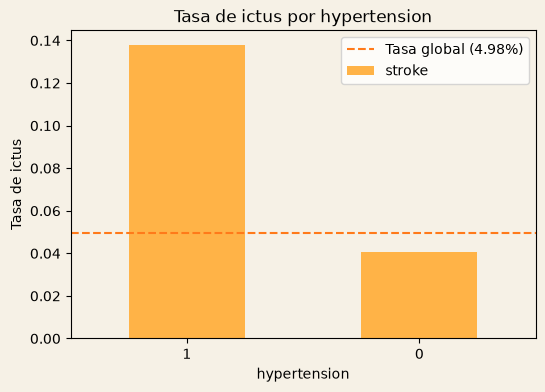

In [16]:
tasa_hypertension = df.groupby("hypertension")["stroke"].mean().sort_values(ascending=False)
print(tasa_hypertension)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_hypertension.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por hypertension")
ax.set_xlabel("hypertension")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=0)
ax.legend()
plt.show()

### heart_disease vs stroke

heart_disease
1    0.170909
0    0.042711
Name: stroke, dtype: float64


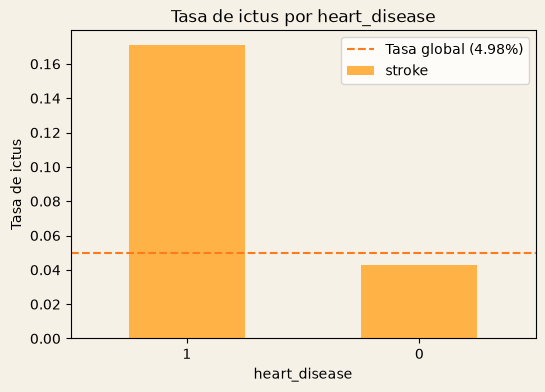

In [17]:
tasa_heart_disease = df.groupby("heart_disease")["stroke"].mean().sort_values(ascending=False)
print(tasa_heart_disease)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_heart_disease.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por heart_disease")
ax.set_xlabel("heart_disease")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=0)
ax.legend()
plt.show()

### avg_glucose_level vs stroke

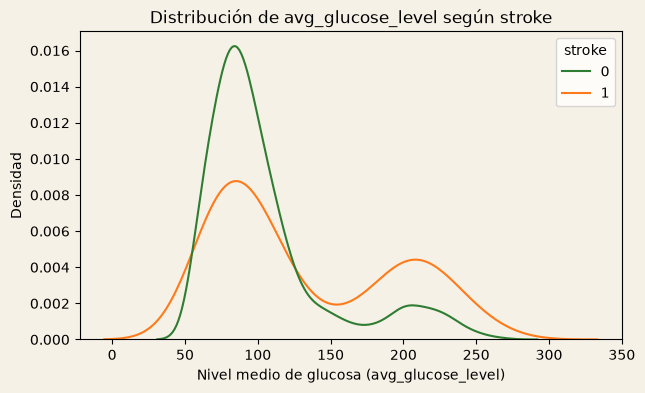

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
sns.kdeplot(data=df, x="avg_glucose_level", hue="stroke", common_norm=False,
            palette={0: COLOR_SANO, 1: COLOR_ICTUS}, ax=ax)
ax.set_title("Distribución de avg_glucose_level según stroke")
ax.set_xlabel("Nivel medio de glucosa (avg_glucose_level)")
ax.set_ylabel("Densidad")
plt.show()

avg_glucose_level
(50, 75]      0.043278
(75, 100]     0.032911
(100, 125]    0.038703
(125, 150]    0.038168
(150, 175]    0.073171
(175, 200]    0.152439
(200, 225]    0.129412
(225, 250]    0.125926
(250, 275]    0.200000
Name: stroke, dtype: float64


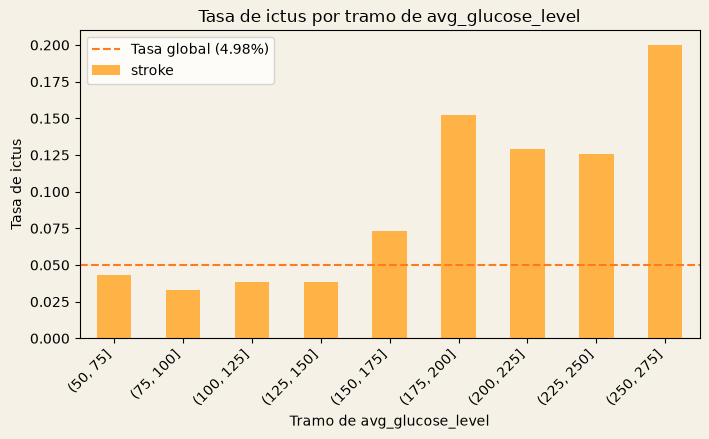

In [ ]:

bins_glucosa = [50, 75, 100, 125, 150, 175, 200, 225, 250, 275]
tramo_glucosa = pd.cut(df["avg_glucose_level"], bins=bins_glucosa)
tasa_glucosa = df.groupby(tramo_glucosa, observed=True)["stroke"].mean()
print(tasa_glucosa)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_glucosa.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por tramo de avg_glucose_level")
ax.set_xlabel("Tramo de avg_glucose_level")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.show()

### age vs stroke

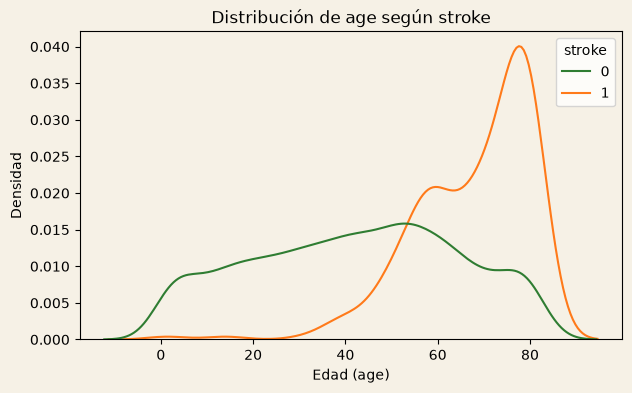

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
sns.kdeplot(data=df, x="age", hue="stroke", common_norm=False,
            palette={0: COLOR_SANO, 1: COLOR_ICTUS}, ax=ax)
ax.set_title("Distribución de age según stroke")
ax.set_xlabel("Edad (age)")
ax.set_ylabel("Densidad")
plt.show()

age
(0, 20]     0.002024
(20, 30]    0.000000
(30, 40]    0.009119
(40, 50]    0.019718
(50, 60]    0.061327
(60, 70]    0.083475
(70, 80]    0.177665
(80, 90]    0.198276
Name: stroke, dtype: float64


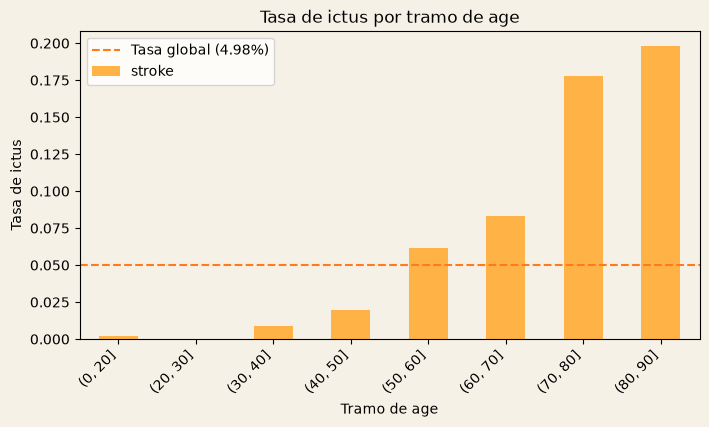

In [21]:
bins_edad = [0, 20, 30, 40, 50, 60, 70, 80, 90]
tramo_edad = pd.cut(df["age"], bins=bins_edad)
tasa_edad = df.groupby(tramo_edad, observed=True)["stroke"].mean()
print(tasa_edad)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_edad.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por tramo de age")
ax.set_xlabel("Tramo de age")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.show()

### smoking_status vs stroke

smoking_status
formerly smoked    0.080738
smokes             0.054124
never smoked       0.048422
Unknown            0.031333
Name: stroke, dtype: float64


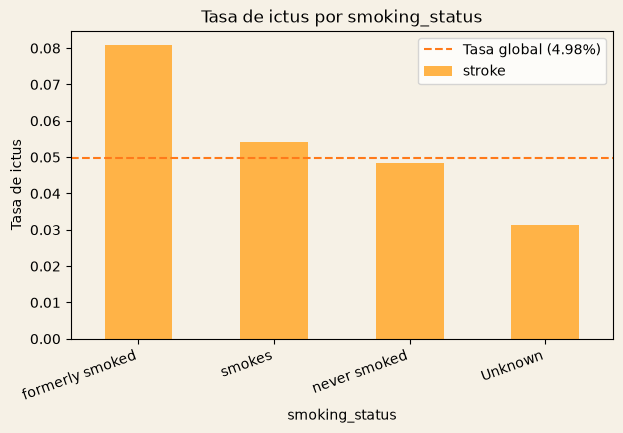

In [22]:
tasa_smoking_status = df.groupby("smoking_status")["stroke"].mean().sort_values(ascending=False)
print(tasa_smoking_status)

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_smoking_status.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por smoking_status")
ax.set_xlabel("smoking_status")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=20, ha="right")
ax.legend()
plt.show()

### ever_married vs stroke

ever_married
Yes    0.066768
No     0.017049
Name: stroke, dtype: float64


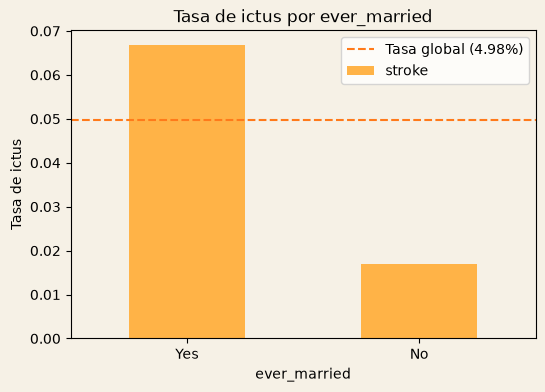

In [23]:
tasa_ever_married = df.groupby("ever_married")["stroke"].mean().sort_values(ascending=False)
print(tasa_ever_married)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_ever_married.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por ever_married")
ax.set_xlabel("ever_married")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=0)
ax.legend()
plt.show()

### work_type vs stroke

work_type
Self-employed    0.080846
Private          0.051748
Govt_job         0.051242
children         0.002972
Name: stroke, dtype: float64


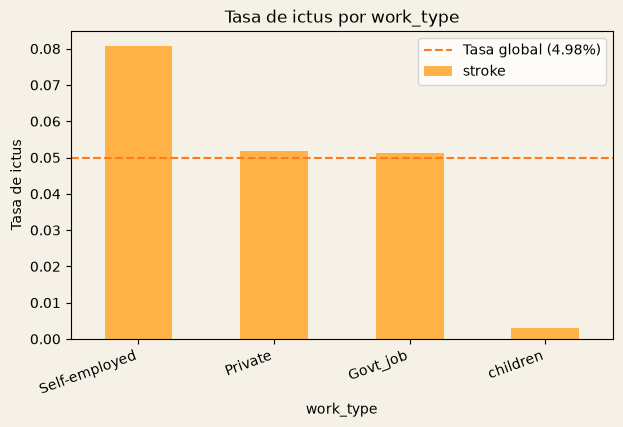

In [24]:
tasa_work_type = df.groupby("work_type")["stroke"].mean().sort_values(ascending=False)
print(tasa_work_type)

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_work_type.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por work_type")
ax.set_xlabel("work_type")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=20, ha="right")
ax.legend()
plt.show()

### Residence_type vs stroke

Residence_type
Urban    0.053318
Rural    0.046141
Name: stroke, dtype: float64


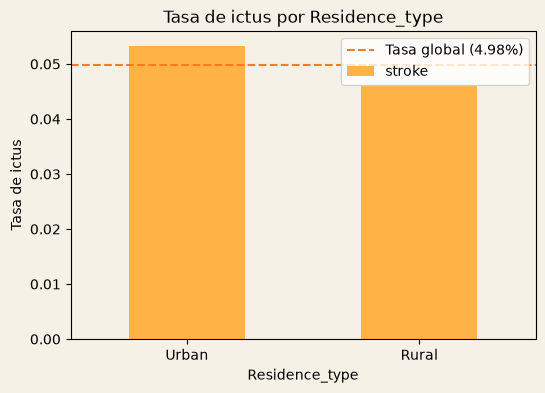

In [25]:
tasa_residence_type = df.groupby("Residence_type")["stroke"].mean().sort_values(ascending=False)
print(tasa_residence_type)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_residence_type.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por Residence_type")
ax.set_xlabel("Residence_type")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=0)
ax.legend()
plt.show()

### gender vs stroke

gender
Male      0.052073
Female    0.048160
Name: stroke, dtype: float64


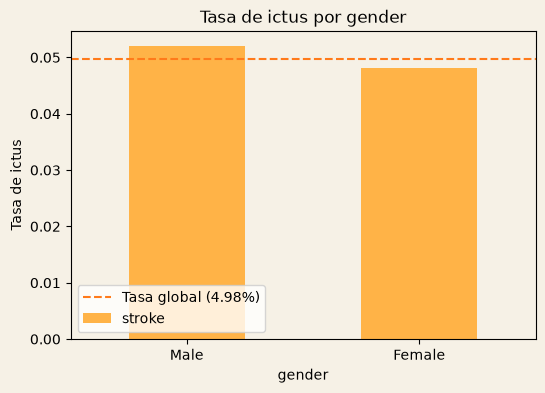

In [26]:
tasa_gender = df.groupby("gender")["stroke"].mean().sort_values(ascending=False)
print(tasa_gender)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_gender.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por gender")
ax.set_xlabel("gender")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=0)
ax.legend()
plt.show()

### bmi vs stroke

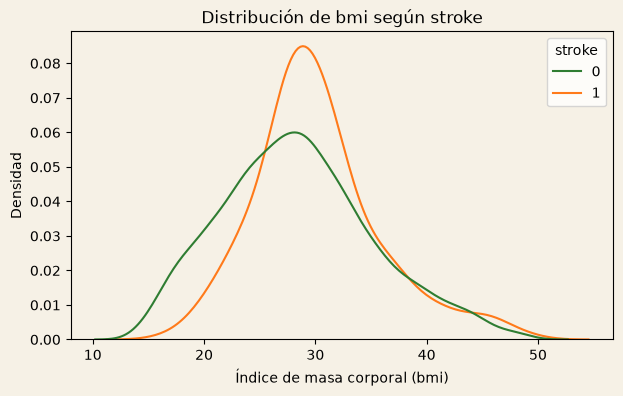

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
sns.kdeplot(data=df, x="bmi", hue="stroke", common_norm=False,
            palette={0: COLOR_SANO, 1: COLOR_ICTUS}, ax=ax)
ax.set_title("Distribución de bmi según stroke")
ax.set_xlabel("Índice de masa corporal (bmi)")
ax.set_ylabel("Densidad")
plt.show()

bmi
(10, 15]    0.000000
(15, 20]    0.007984
(20, 25]    0.032864
(25, 30]    0.067333
(30, 35]    0.062558
(35, 40]    0.047904
(40, 45]    0.043825
(45, 50]    0.092308
Name: stroke, dtype: float64


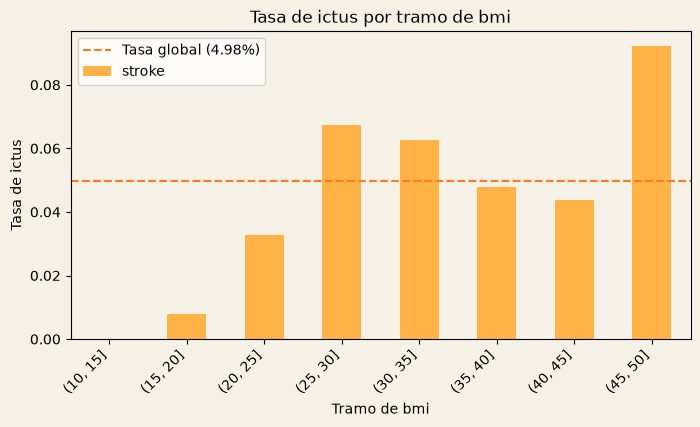

In [ ]:

bins_bmi = [10, 15, 20, 25, 30, 35, 40, 45, 50]
tramo_bmi = pd.cut(df["bmi"], bins=bins_bmi)
tasa_bmi = df.groupby(tramo_bmi, observed=True)["stroke"].mean()
print(tasa_bmi)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
tasa_bmi.plot(kind="bar", color=COLOR_ACENTO, ax=ax)
ax.axhline(tasa_global, color=COLOR_ICTUS, linestyle="--", linewidth=1.5,
           label=f"Tasa global ({tasa_global:.2%})")
ax.set_title("Tasa de ictus por tramo de bmi")
ax.set_xlabel("Tramo de bmi")
ax.set_ylabel("Tasa de ictus")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.show()

#### Chequeo de proxy — edad media por grupo

Tres variables (`ever_married`, `work_type`, `smoking_status`) mostraron asociación con `stroke` en el bivariado, pero se sospechaba que fuera edad prestada y no señal propia. Este chequeo cruza cada una con su edad media por grupo: si el grupo con más ictus es también el más mayor, la asociación se explica por la edad.

In [ ]:

for col in ["ever_married", "work_type", "smoking_status"]:
    print(df.groupby(col)["age"].mean().sort_values(ascending=False))
    print("-" * 40)

ever_married
Yes    54.469817
No     22.112475
Name: age, dtype: float64
----------------------------------------
work_type
Self-employed    60.300995
Govt_job         50.880435
Private          45.586364
children          6.906865
Name: age, dtype: float64
----------------------------------------
smoking_status
formerly smoked    55.044983
smokes             47.159794
never smoked       47.053319
Unknown            30.313547
Name: age, dtype: float64
----------------------------------------


### Conclusiones — Bivariado vs stroke

El bivariado concentra la señal en las cuatro variables clínicas. `age` es el predictor más limpio y el único con gradiente continuo: la tasa de ictus es casi nula por debajo de los 20, cruza la media global (4,98 %) al entrar en los 50 y llega a ~20 % en (80,90], con las distribuciones de ambos grupos claramente separadas en el KDE y el pico de casos hacia los 78 años. `heart_disease` e `hypertension` operan como saltos binarios: la cardiopatía lleva la tasa a ~17 % y la hipertensión a ~14 %, más del triple del 4,98 % general, mientras que su ausencia deja el riesgo por debajo de la media. `avg_glucose_level` no sube de forma pareja sino por umbral: hasta ~150 las tasas rondan el 3–4 % y solo por encima escalan hasta ~15 % en (175,200] y ~20 % en el tramo más alto, lo que en el KDE aparece como una segunda loma de casos en torno a 200 que el grupo sano no tiene.

Tres variables muestran asociación mediada por la edad, confirmada al cruzar cada grupo con su edad media. `ever_married` es proxy directo: los casados hacen ictus a 6,7 % frente a 1,7 % de los no casados, pero promedian 54,5 años contra 22,1, de modo que a igualdad de edad el estado civil probablemente no aporte nada. `work_type` repite el patrón en sus extremos: los `Self-employed` marcan el techo (8,1 % de ictus, 60,3 años de media) y los `children` el piso (0,3 %, 6,9 años), diferencia explicada por la edad y no por la ocupación. `smoking_status` es el caso mixto: la tasa alta de los ex fumadores (8,1 %) se apoya en que son los más mayores (55 años), pero al comparar fumadores actuales y quienes nunca fumaron —ambos con edad media de 47 años— persiste una diferencia de riesgo (5,4 % vs 4,8 %) que, por darse a igualdad de edad, sugiere un efecto propio del tabaco, pequeño y no contrastado con test estadístico. El `Unknown`, el más bajo (3,1 %), se explica por ser 90 % niños, no por efecto protector.

Dos variables resultan planas, y es un hallazgo medido, no una ausencia de análisis: `Residence_type` (Urban 5,3 % vs Rural 4,6 %) y `gender` (Male 5,2 % vs Female 4,8 %) apenas se despegan de la media global, sin separación relevante. No aportan señal individual y son las primeras candidatas a quedar fuera del modelo, con la decisión diferida al modelado.

`bmi` queda como caso aparte: continua y clínicamente plausible, muestra señal pero no limpia. El riesgo sube desde el bajo peso hasta ~6,7 % en sobrepeso (25–30) y se mantiene en torno al 6 % en obesidad leve, con un salto a 9,2 % en el tramo extremo (45,50] sospechoso de apoyarse en muy pocos casos, verificable con el conteo por tramo. Es la única del barrido con candidatura real a señal propia, aunque su forma no lineal sugiere que parte del efecto puede compartirse con la edad.

En conjunto, el bivariado ordena a las diez variables en cuatro grupos —fuertes con señal plausiblemente propia (`age`, `heart_disease`, `hypertension`, `avg_glucose_level`), señal mediada por la edad (`ever_married`, `work_type`, `smoking_status`, este último con un residuo propio), planas (`Residence_type`, `gender`) y un caso mixto (`bmi`)— pero ninguna se incluye ni se descarta en esta fase. La herramienta muestra si hay asociación y, con el chequeo de edad, permitió anticipar cuáles son proxy; confirmar qué señal sobrevive al controlar todas las variables juntas es el trabajo del multivariado.

## Fase 4 — Multivariado

In [30]:
from matplotlib.colors import LinearSegmentedColormap

# Divergente (correlación: negativo -> cero -> positivo): verde -> crema -> naranja
CMAP_DIV = LinearSegmentedColormap.from_list("citrus_div", ["#2F7D32", "#F6F1E6", "#FF7A1A"])
# Secuencial (tasas: 0 -> alto): crema -> naranja claro -> naranja
CMAP_SEQ = LinearSegmentedColormap.from_list("citrus_seq", ["#F6F1E6", "#FFB347", "#FF7A1A"])

# Bandas reutilizables (mismos cortes que en el bivariado); prefijo "_" = columnas internas del EDA
df["_age_band"] = pd.cut(df["age"], bins=[0, 20, 30, 40, 50, 60, 70, 80, 90])
df["_glucose_band"] = pd.cut(df["avg_glucose_level"], bins=[50, 75, 100, 125, 150, 175, 200, 225, 250, 275])

### Matriz de correlación

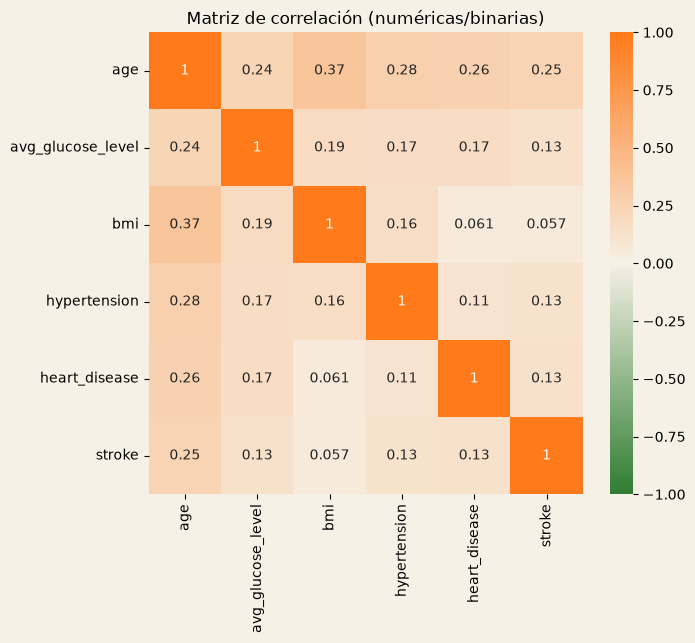

In [ ]:

cols_corr = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]
corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)
sns.heatmap(corr, annot=True, cmap=CMAP_DIV, center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación (numéricas/binarias)")
plt.show()

### Proxy bajo control de edad

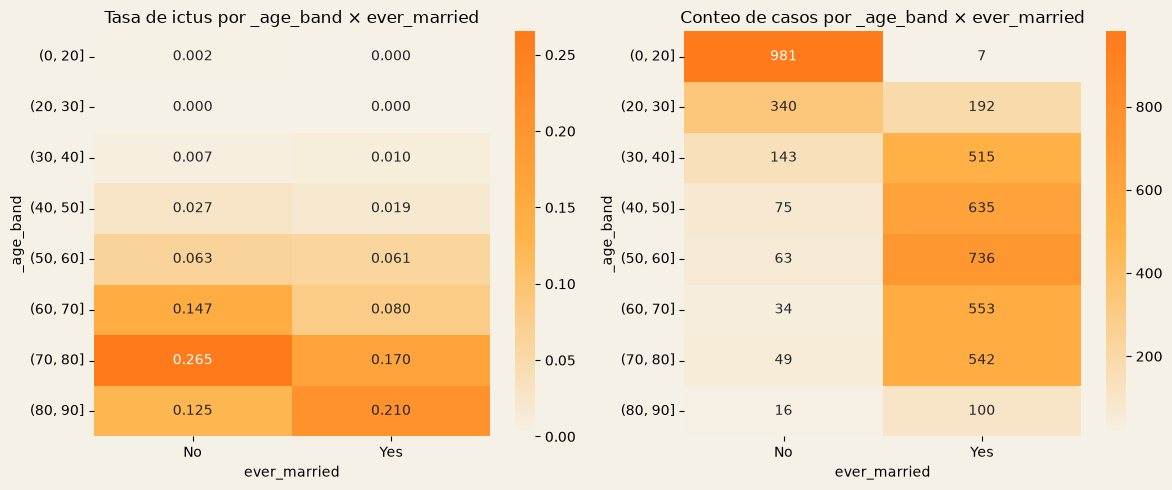

In [32]:
tasa_edad_ever_married = pd.pivot_table(df, index="_age_band", columns="ever_married",
                                         values="stroke", aggfunc="mean", observed=True)
conteo_edad_ever_married = pd.pivot_table(df, index="_age_band", columns="ever_married",
                                           values="stroke", aggfunc="count", observed=True).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(COLOR_FONDO)
sns.heatmap(tasa_edad_ever_married, annot=True, fmt=".3f", cmap=CMAP_SEQ, ax=axes[0])
axes[0].set_title("Tasa de ictus por _age_band × ever_married")
sns.heatmap(conteo_edad_ever_married, annot=True, fmt="d", cmap=CMAP_SEQ, ax=axes[1])
axes[1].set_title("Conteo de casos por _age_band × ever_married")
plt.tight_layout()
plt.show()

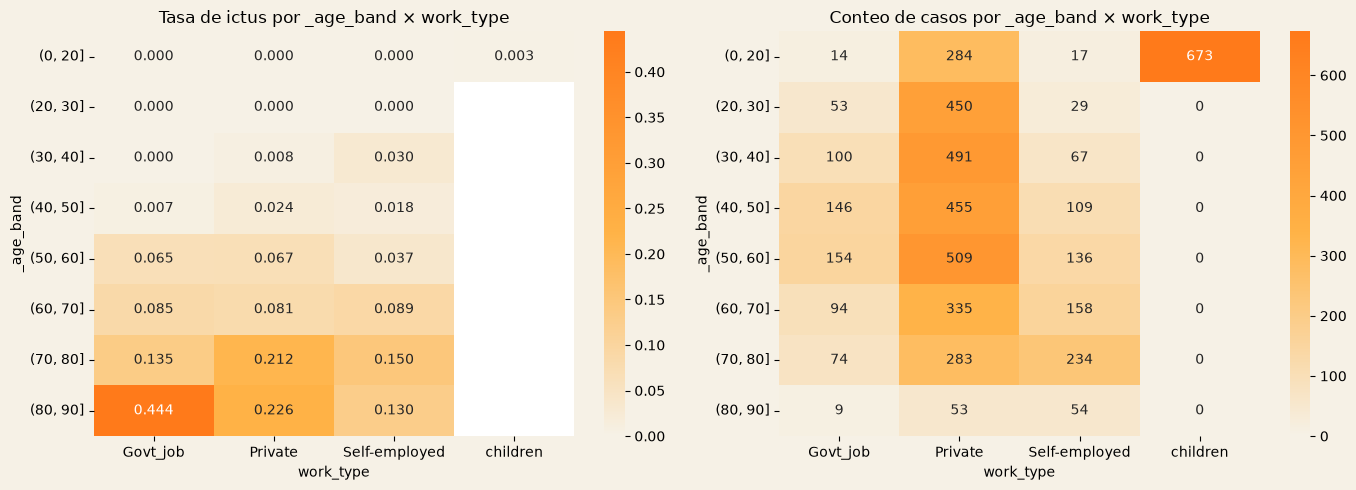

In [33]:
tasa_edad_work_type = pd.pivot_table(df, index="_age_band", columns="work_type",
                                      values="stroke", aggfunc="mean", observed=True)
conteo_edad_work_type = pd.pivot_table(df, index="_age_band", columns="work_type",
                                        values="stroke", aggfunc="count", observed=True).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLOR_FONDO)
sns.heatmap(tasa_edad_work_type, annot=True, fmt=".3f", cmap=CMAP_SEQ, ax=axes[0])
axes[0].set_title("Tasa de ictus por _age_band × work_type")
sns.heatmap(conteo_edad_work_type, annot=True, fmt="d", cmap=CMAP_SEQ, ax=axes[1])
axes[1].set_title("Conteo de casos por _age_band × work_type")
plt.tight_layout()
plt.show()

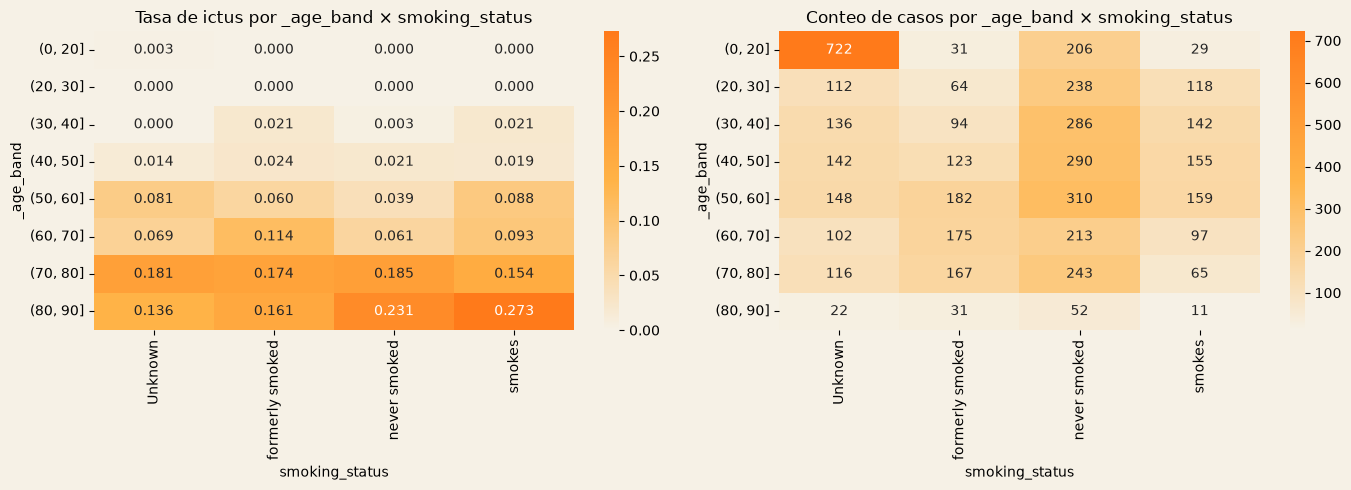

In [34]:
tasa_edad_smoking_status = pd.pivot_table(df, index="_age_band", columns="smoking_status",
                                           values="stroke", aggfunc="mean", observed=True)
conteo_edad_smoking_status = pd.pivot_table(df, index="_age_band", columns="smoking_status",
                                             values="stroke", aggfunc="count", observed=True).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLOR_FONDO)
sns.heatmap(tasa_edad_smoking_status, annot=True, fmt=".3f", cmap=CMAP_SEQ, ax=axes[0])
axes[0].set_title("Tasa de ictus por _age_band × smoking_status")
sns.heatmap(conteo_edad_smoking_status, annot=True, fmt="d", cmap=CMAP_SEQ, ax=axes[1])
axes[1].set_title("Conteo de casos por _age_band × smoking_status")
plt.tight_layout()
plt.show()

### Interacciones: edad × factor clínico

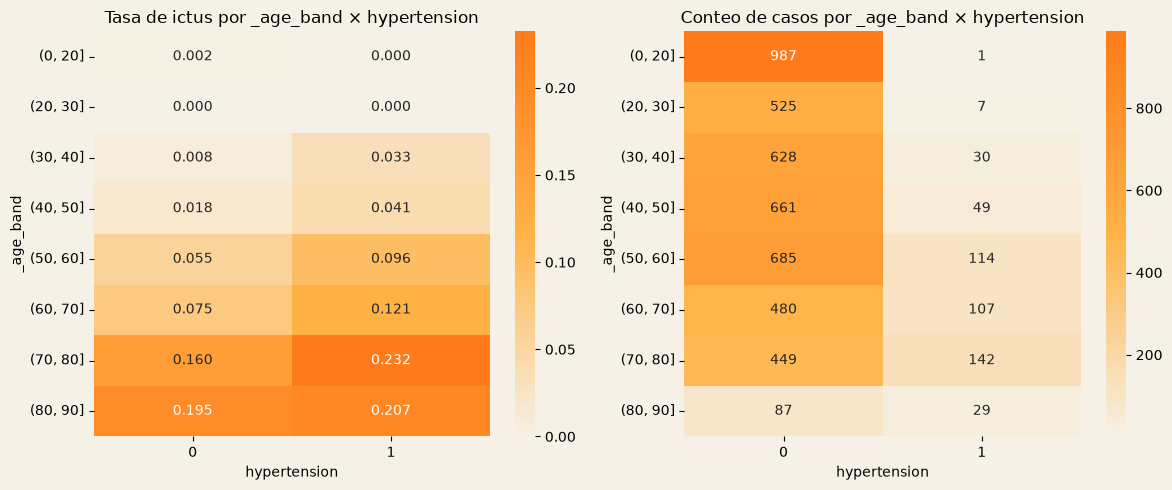

In [35]:
tasa_edad_hypertension = pd.pivot_table(df, index="_age_band", columns="hypertension",
                                         values="stroke", aggfunc="mean", observed=True)
conteo_edad_hypertension = pd.pivot_table(df, index="_age_band", columns="hypertension",
                                           values="stroke", aggfunc="count", observed=True).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(COLOR_FONDO)
sns.heatmap(tasa_edad_hypertension, annot=True, fmt=".3f", cmap=CMAP_SEQ, ax=axes[0])
axes[0].set_title("Tasa de ictus por _age_band × hypertension")
sns.heatmap(conteo_edad_hypertension, annot=True, fmt="d", cmap=CMAP_SEQ, ax=axes[1])
axes[1].set_title("Conteo de casos por _age_band × hypertension")
plt.tight_layout()
plt.show()

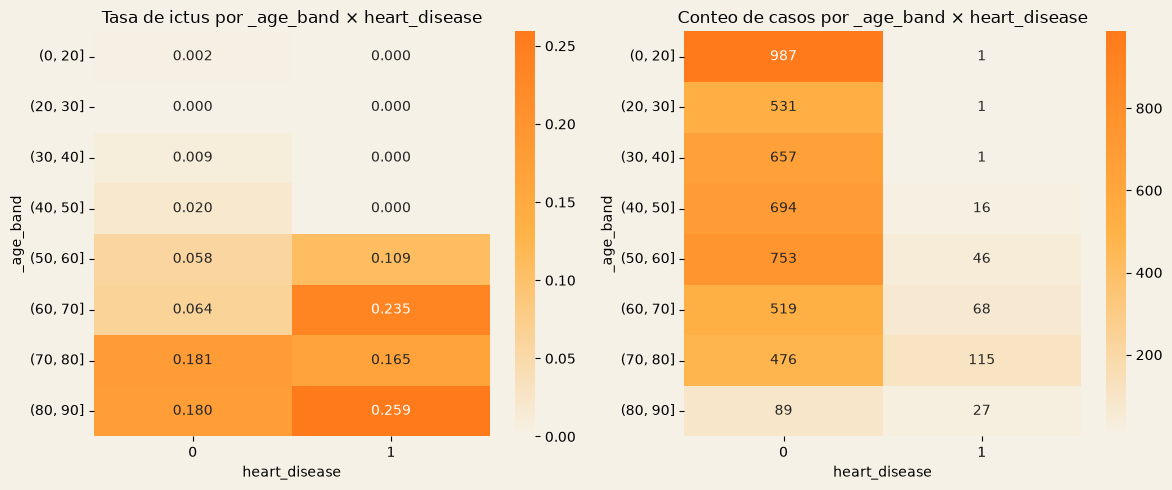

In [36]:
tasa_edad_heart_disease = pd.pivot_table(df, index="_age_band", columns="heart_disease",
                                          values="stroke", aggfunc="mean", observed=True)
conteo_edad_heart_disease = pd.pivot_table(df, index="_age_band", columns="heart_disease",
                                            values="stroke", aggfunc="count", observed=True).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(COLOR_FONDO)
sns.heatmap(tasa_edad_heart_disease, annot=True, fmt=".3f", cmap=CMAP_SEQ, ax=axes[0])
axes[0].set_title("Tasa de ictus por _age_band × heart_disease")
sns.heatmap(conteo_edad_heart_disease, annot=True, fmt="d", cmap=CMAP_SEQ, ax=axes[1])
axes[1].set_title("Conteo de casos por _age_band × heart_disease")
plt.tight_layout()
plt.show()

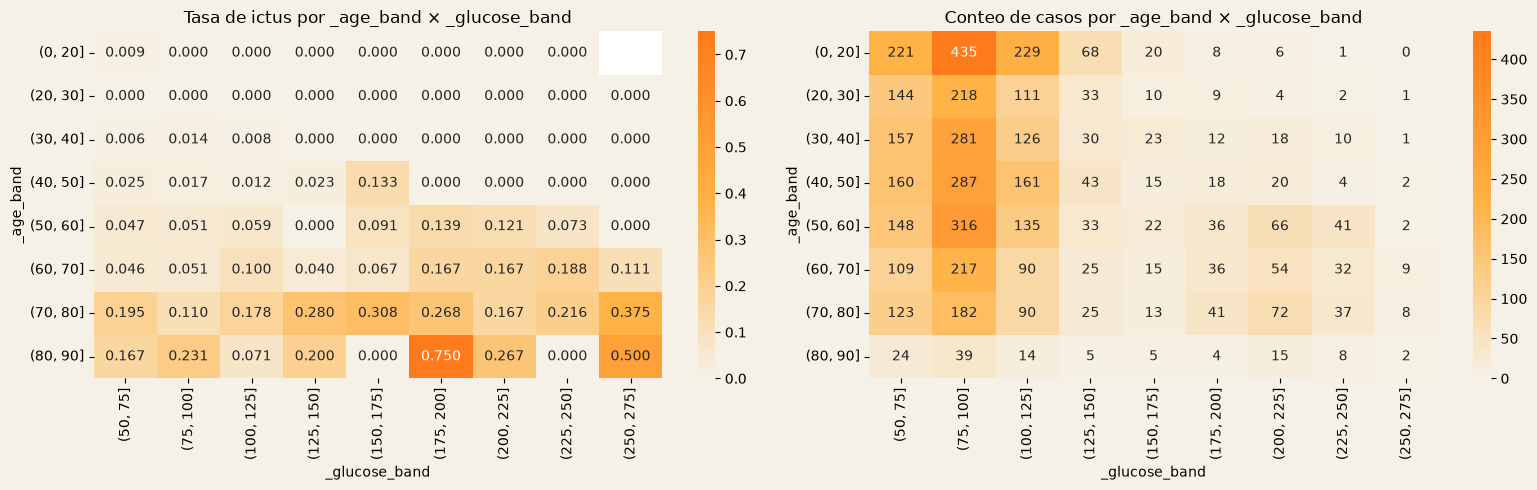

In [37]:
tasa_edad_glucose_band = pd.pivot_table(df, index="_age_band", columns="_glucose_band",
                                         values="stroke", aggfunc="mean", observed=True)
conteo_edad_glucose_band = pd.pivot_table(df, index="_age_band", columns="_glucose_band",
                                           values="stroke", aggfunc="count", observed=True).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(COLOR_FONDO)
sns.heatmap(tasa_edad_glucose_band, annot=True, fmt=".3f", cmap=CMAP_SEQ, ax=axes[0])
axes[0].set_title("Tasa de ictus por _age_band × _glucose_band")
sns.heatmap(conteo_edad_glucose_band, annot=True, fmt="d", cmap=CMAP_SEQ, ax=axes[1])
axes[1].set_title("Conteo de casos por _age_band × _glucose_band")
plt.tight_layout()
plt.show()

### Acumulación de factores de riesgo

In [ ]:

df["_n_riesgo"] = df["hypertension"] + df["heart_disease"] + (df["avg_glucose_level"] > 150).astype(int)

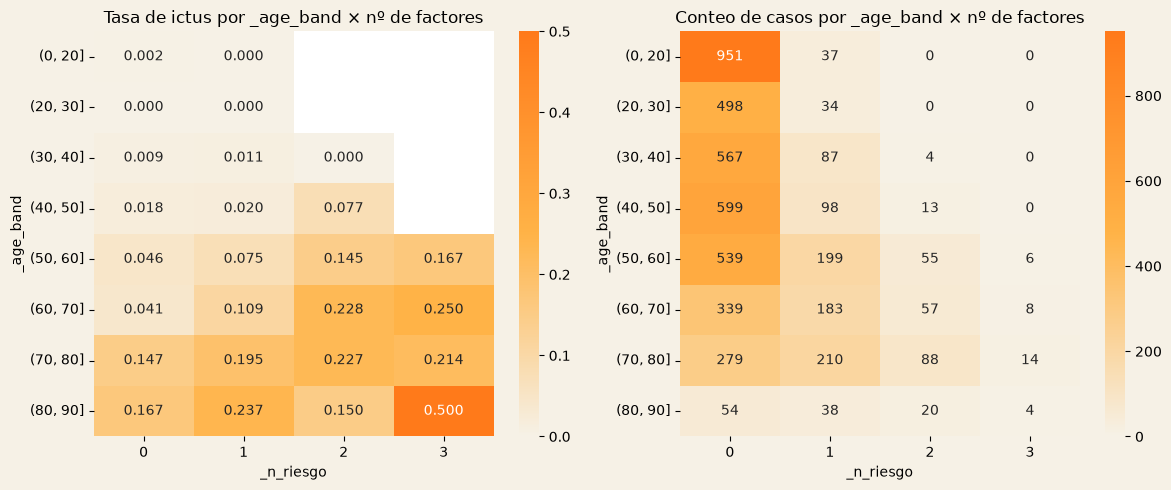

In [ ]:

tasa_edad_n_riesgo = pd.pivot_table(df, index="_age_band", columns="_n_riesgo",
                                     values="stroke", aggfunc="mean", observed=True)
conteo_edad_n_riesgo = pd.pivot_table(df, index="_age_band", columns="_n_riesgo",
                                       values="stroke", aggfunc="count", observed=True).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(COLOR_FONDO)
sns.heatmap(tasa_edad_n_riesgo, annot=True, fmt=".3f", cmap=CMAP_SEQ, ax=axes[0])
axes[0].set_title("Tasa de ictus por _age_band × nº de factores")
sns.heatmap(conteo_edad_n_riesgo, annot=True, fmt="d", cmap=CMAP_SEQ, ax=axes[1])
axes[1].set_title("Conteo de casos por _age_band × nº de factores")
plt.tight_layout()
plt.show()

In [41]:


df.drop(columns=["_age_band", "_glucose_band", "_n_riesgo"], inplace=True, errors="ignore")

### Conclusiones — Multivariado

El multivariado abre con la matriz de correlación, que da la vista panorámica y confirma por una vía independiente lo que el bivariado ya mostraba: en la fila de `stroke`, `age` encabeza con 0,25, seguida por `avg_glucose_level`, `hypertension` y `heart_disease` empatadas en torno a 0,13, y `bmi` casi en cero (0,057). Ese último valor no significa que `bmi` no importe, sino que Pearson solo capta relación lineal y la de `bmi` con el ictus no lo es —sube, mesetea y salta—, de modo que la herramienta la subestima por construcción. La matriz también deja ver la huella del proxy antes de resolverlo: `age` correlaciona con casi todas las demás (0,37 con `bmi`, 0,28 con `hypertension`, 0,26 con `heart_disease`), señal de que las variables están entrelazadas con la edad. Pero la correlación es por pares y no puede decir si un factor aporta algo una vez descontada la edad: abre la pregunta, no la cierra.

La estratificación por banda de edad cierra esa pregunta para las tres variables sospechosas de proxy, leyendo cada fila a edad fija. `ever_married` queda confirmada como proxy: en la franja (50,60], la única con población sólida en ambos lados (63 no casados y 736 casados), las tasas son casi idénticas (0,063 vs 0,061), de modo que la brecha enorme del bivariado (6,7 % vs 1,7 %) era edad y no estado civil. `work_type` corre la misma suerte por partida doble: la categoría `children` es literalmente una banda de edad (sus 673 casos están todos en (0,20] y ninguno fuera), y las tres ocupaciones restantes, a igualdad de edad, dan tasas equivalentes (en (60,70], 0,085 / 0,081 / 0,089 con conteos de 94, 335 y 158). Ambas son ahora candidatas firmes a quedar fuera del modelo, porque no aportan información que la edad no tenga ya. `smoking_status`, en cambio, no se resuelve como proxy: al comparar quienes nunca fumaron contra fumadores actuales a igual edad, la diferencia aparece en algunas franjas bien pobladas (en (50,60], 0,039 vs 0,088 con 310 y 159 personas) pero se iguala o se invierte en otras, dejando una señal débil e inconsistente. No es proxy puro, pero tampoco un predictor limpio; su permanencia en el modelo queda como decisión diferida.

El bloque de interacciones confirma que las tres variables clínicas tienen efecto propio —no prestado de la edad— porque a edad fija el grupo con el factor supera al grupo sin él en las filas pobladas. `hypertension` es el caso más nítido: además del efecto propio, su aporte crece de forma ordenada con la edad, de +0,023 puntos de tasa en (40,50] a +0,072 en (70,80], lo que sugiere una interacción real, con la hipertensión pesando más cuanto mayor es el paciente. `heart_disease` confirma efecto propio y fuerte (en (60,70], 0,064 sin cardiopatía frente a 0,235 con ella, sobre 519 y 68 personas), pero su patrón de interacción es irregular y no dibuja la escalera limpia de la hipertensión, probablemente sacudido por los conteos chicos de la columna con cardiopatía. `avg_glucose_level` confirma su efecto propio por umbral —a igualdad de edad, cruzar a glucosa alta (150+) sube la tasa, visible en las franjas 40–80 bien pobladas—, pero la forma de su interacción con la edad no se puede leer limpia porque la zona de glucosa alta está poblada por muy pocos casos; las celdas más intensas del heatmap (0,750 y 0,500 en la fila de mayores) se apoyan en 4 y 2 personas y son ruido, no patrón.

El heatmap de acumulación de factores es el que más apoya la hipótesis de partida. A igualdad de edad, sumar factores de riesgo eleva la tasa de forma monótona en el tramo de 0 a 2 factores, con población sólida: en (50,60] va de 0,046 a 0,145 y en (60,70] de 0,041 a 0,228. Leído en la otra dirección, a número de factores fijo la tasa también sube con la edad, de modo que edad y acumulación actúan de forma aditiva, sumando riesgo por separado y en conjunto. La única reserva es la columna de 3 factores, apoyada en muy pocos casos (6, 8, 14 y 4 personas según la franja) y por tanto coherente con la tendencia pero no concluyente por sí sola; las celdas en blanco no son riesgo cero sino combinaciones que no existen en el dataset, ya que ningún menor de 40 acumula tres factores. El mensaje firme es el tramo de 0 a 2 factores, que confirma con dato propio que el riesgo no depende de un factor aislado sino de su acumulación sobre una base de edad.

En conjunto, el multivariado reordena lo que el bivariado había dejado abierto. `age` se confirma como eje del riesgo, entrelazado con casi todo. Las tres variables clínicas —`hypertension`, `heart_disease` y `avg_glucose_level`— pasan la prueba de la estratificación con efecto propio y no prestado, y entran como candidatas firmes al modelo. `ever_married` y `work_type` quedan confirmadas como proxy de edad y son las primeras candidatas a descartar. `smoking_status` y `bmi` quedan como decisión diferida: la primera por su señal débil e inconsistente, la segunda porque su relación no lineal la vuelve invisible a la correlación aunque el bivariado le viera forma. Toda esta lectura es visual, sobre grupos de tamaño desigual y sin test estadístico: distingue efecto propio de edad prestada y sugiere interacciones, pero confirmar que esas diferencias no son azar, y cuantificar el peso de cada variable con todas controladas a la vez, es el trabajo del modelado. El EDA deja el terreno mapeado; la decisión final de qué entra y con cuánto peso la toma el modelo.